# Анализ системы метрик приложения

Приложение ******, которое предоставляет пользователям доступ к развлекательному контенту: видео, подкастам и блогам. Пользователи могут выбрать несколько пакетов контента. Пакеты различаются по цене, объёму и содержанию.

К началу лета в приложении появился новый вид контента — спортивный. С его помощью менеджеры стремятся расширить аудиторию, добавив в неё пользователей, которые увлекаются спортом и здоровым образом жизни.

К запуску нового контента была скорректирована маркетинговая стратегия привлечения пользователей. Согласно бизнес-модели продукта, привлечение должно окупиться за первые 28 дней (4 недели).

После запуска нового контента и изменения стратегии интерес к продукту в целом вырос, но выручка начала стагнировать. Нужно разобраться, почему это происходит.

Ваши задачи:
- провести анализ юнит-экономики продукта в динамике за первые 28 дней;
- разобраться в причинах стагнации выручки;
- определить, какие источники привлечения приносят прибыль, а какие не выходят на уровень окупаемости;
- дать рекомендации отделу маркетинга.


### Данные

Есть данные о посещениях приложения, покупках и расходах на маркетинг.
Данные собраны в трёх датасетах.

1. Датасет `ppro_visits.csv` — информация о посещениях приложения пользователями, которые зарегистрировались с 1 апреля 2024 года по 30 ноября 2024 года:
    - `user_id` — уникальный идентификатор пользователя;
    - `region` — страна пользователя;
    - `device` — категория устройства пользователя;
    - `channel` — идентификатор рекламного источника, из которого пришёл пользователь;
    - `session_start` — дата и время начала сессии;
    - `session_end` — дата и время окончания сессии.

2. Датасет `ppro_orders.csv` — информация о покупках:
    - `user_id` — уникальный идентификатор пользователя, который сделал покупку;
    - `event_dt` — дата и время покупки;
    - `revenue` — выручка.

3. Датасет `ppro_costs.csv` — информация о затратах на маркетинг:
    - `dt` — дата
    - `channel` — идентификатор рекламного источника;
    - `costs` — затраты на этот рекламный источник в этот день.
    
### План проекта
- Загрузить и предобработать данные.
- Подготовить данные для когортного анализа.
- Рассчитать и проанализировать метрики вовлечённости в продукт.
- Рассчитать и проанализировать финансовые метрики CAC, LTV и ROI за первые 28 дней с момента привлечения.
- Исследовать метрики в разрезе источника привлечения.
- Рассчитать период окупаемости маркетинговых вложений.
- Сформулировать выводы и рекомендации.


## Загрузка и предобработка данных

Загрузите данные и получите основную информацию о них. Проведите необходимую предобработку. Основную информацию о данных и предобработке зафиксируйте в кратком промежуточном выводе.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
visits = pd.read_csv('/datasets/ppro_visits.csv')
orders = pd.read_csv('/datasets/ppro_orders.csv')
costs = pd.read_csv('/datasets/ppro_costs.csv')

In [3]:
display(visits)
visits.info()

,user_id,region,device,channel,session_start,session_end
0,631105188566,India,desktop,MediaTornado,2024-04-01 03:48:00,2024-04-01 04:19:00
1,892885906464,India,tv,RocketSuperAds,2024-04-01 00:47:00,2024-04-01 01:14:00
2,517003690029,India,mobile,MediaTornado,2024-04-01 17:31:00,2024-04-01 17:53:00
3,185156659289,India,mobile,MediaTornado,2024-04-01 14:36:00,2024-04-01 14:51:00
4,409503040345,India,mobile,RocketSuperAds,2024-04-01 08:25:00,2024-04-01 08:45:00
...,...,...,...,...,...,...
161860,173722594460,India,desktop,MediaTornado,2024-11-30 02:12:00,2024-11-30 02:40:00
161861,711873273862,India,mobile,FaceBoom,2024-11-30 05:31:00,2024-11-30 05:55:00
161862,797604836232,India,mobile,TipTop,2024-11-30 09:55:00,2024-11-30 09:56:00
161863,188139897674,India,desktop,MediaTornado,2024-11-30 02:12:00,2024-11-30 02:36:00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161865 entries, 0 to 161864
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   user_id        161865 non-null  int64 
 1   region         161865 non-null  object
 2   device         161865 non-null  object
 3   channel        161865 non-null  object
 4   session_start  161865 non-null  object
 5   session_end    161865 non-null  object
dtypes: int64(1), object(5)
memory usage: 7.4+ MB


In [4]:
display(orders)
orders.info()

,user_id,event_dt,revenue
0,771951256319,2024-04-01 05:56:26,2.99
1,829942381059,2024-04-01 14:55:02,2.99
2,727879856738,2024-04-01 22:15:09,14.99
3,481270888930,2024-04-01 06:05:14,2.99
4,844695029762,2024-04-01 01:19:52,2.99
...,...,...,...
33888,397577560536,2024-11-30 16:47:45,2.99
33889,610390409217,2024-11-30 04:35:45,7.99
33890,74116424793,2024-11-30 04:16:46,2.99
33891,691138256176,2024-11-30 02:07:03,2.99


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33893 entries, 0 to 33892
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   33893 non-null  int64  
 1   event_dt  33893 non-null  object 
 2   revenue   33893 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 794.5+ KB


In [5]:
display(costs)
costs.info()

,dt,channel,costs
0,2024-04-01,FaceBoom,124.938874
1,2024-04-02,FaceBoom,88.147779
2,2024-04-03,FaceBoom,120.779457
3,2024-04-04,FaceBoom,98.981253
4,2024-04-05,FaceBoom,109.044760
...,...,...,...
971,2024-11-26,TipTop,216.741490
972,2024-11-27,TipTop,263.071019
973,2024-11-28,TipTop,252.638555
974,2024-11-29,TipTop,261.943208


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   dt       976 non-null    object 
 1   channel  976 non-null    object 
 2   costs    976 non-null    float64
dtypes: float64(1), object(2)
memory usage: 23.0+ KB


<font color='#777778'>
Пропусков нет. <br>
    Даты записаны как строка, преобразуем все столбцы с датой в тип datetime64[ns] для удобства последующих операций: 
</font> 

In [6]:
visits['session_start'] = pd.to_datetime(visits['session_start'])
visits['session_end'] = pd.to_datetime(visits['session_end'])
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161865 entries, 0 to 161864
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   user_id        161865 non-null  int64         
 1   region         161865 non-null  object        
 2   device         161865 non-null  object        
 3   channel        161865 non-null  object        
 4   session_start  161865 non-null  datetime64[ns]
 5   session_end    161865 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(3)
memory usage: 7.4+ MB


In [7]:
orders['event_dt'] = pd.to_datetime(orders['event_dt'])
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33893 entries, 0 to 33892
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   33893 non-null  int64         
 1   event_dt  33893 non-null  datetime64[ns]
 2   revenue   33893 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 794.5 KB


In [8]:
costs['dt'] = pd.to_datetime(costs['dt'])
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   dt       976 non-null    datetime64[ns]
 1   channel  976 non-null    object        
 2   costs    976 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 23.0+ KB


<font color='#777778'>
Посмотрим дубликаты.
</font> 

In [9]:
visits.duplicated().sum() 

0

In [10]:
orders.duplicated().sum()  

0

In [11]:
costs.duplicated().sum()  

0

<font color='#777778'>Явных дубликатов нет.<br>
    Проверим неявные дубликаты в связке идентификатора пользователя и времени действия для датафрейма `visits` и `orders` (время в обоих случаях указано до секунды)<br>
    Для `costs` в связке даты и затрат, которые указанны до шести знаков после запятой.
</font>

In [12]:
visits.duplicated(subset=['user_id', 'session_start']).sum() 

0

In [13]:
orders.duplicated(subset=['user_id', 'event_dt']).sum() 

0

In [14]:
costs.duplicated(subset=['dt', 'costs']).sum() 

0

<font color='#777778'>
Неявных дубликатов тоже нет.<br>
    Проверим наличие выбросов в `orders` и `costs`
</font> 

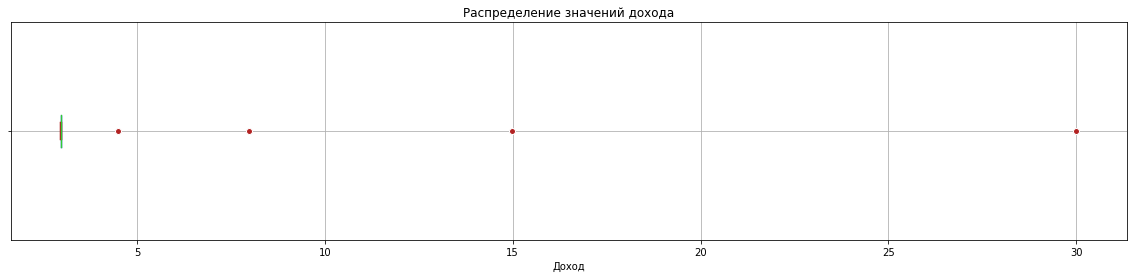

In [15]:
plt.figure(figsize=(20, 4))

orders.boxplot(column='revenue', vert=False,
           boxprops=dict(color='royalblue', linewidth=1.3),
           whiskerprops=dict(color='royalblue', linewidth=1.3),
           capprops=dict(color='firebrick', linewidth=2.3),
           medianprops=dict(color='limegreen', linewidth=1.3),
           flierprops=dict(markerfacecolor='firebrick', marker='o', markeredgecolor= 'white'))

plt.title('Распределение значений дохода')
plt.xlabel('Доход')
plt.gca().set_yticklabels([])

plt.show()

<font color='#777778'>Выбросами в датафрейме `orders` это считать нельзя, такие значения вполне допустимы для столбца revenue.
</font> 

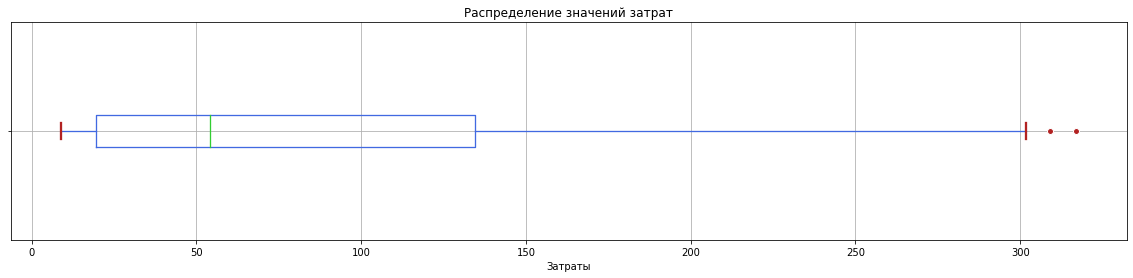

In [16]:
plt.figure(figsize=(20, 4))

costs.boxplot(column='costs', vert=False,
           boxprops=dict(color='royalblue', linewidth=1.3),
           whiskerprops=dict(color='royalblue', linewidth=1.3),
           capprops=dict(color='firebrick', linewidth=2.3),
           medianprops=dict(color='limegreen', linewidth=1.3),
           flierprops=dict(markerfacecolor='firebrick', marker='o', markeredgecolor= 'white'))

plt.title('Распределение значений затрат')
plt.xlabel('Затраты')
plt.gca().set_yticklabels([])

plt.show()

<font color='#777778'>Выбросов в датафрейме `costs` тоже нет.
</font> 

<font color='#00008B'>
<b>Выводы:</b></font><br> 
<font color='#777778'>Данные не содержат пропусков, выбросов, явных и неявных дубликатов.<br>
    Датафрейм <code>visits</code> 161865 строк. Датафрейм <code>orders</code> 33893 строк. Датафрейм <code>costs</code> 976 строк.<br>
    Столбцы с датой во всех датафреймах преобразованны в тип datetime64[ns]. 
    </font> 

## Подготовка данных к когортному анализу

Подготовим данные к когортному анализу с учётом того, что будем изучать окупаемость привлечения пользователей за первые 28 дней.

Для каждого пользователя найдем:
- дату первой сессии (дата привлечения пользователя, `first_dt`);
- канал привлечения (`first_channel`);
- стоимость привлечения пользователя (`cac`).

Результаты сохраним в новой таблице, `profiles`.

Добавим к данным с событиями и покупками информацию о первом источнике привлечения и дату привлечения пользователя из созданной таблицы. После этого рассчитаем дневной лайфтайм для каждого события или покупки и добавим в таблицу в виде целого числа. Будем в дальнейшем при проведении когортного анализа использовать информацию о первом источнике привлечения пользователя.

In [17]:
# Переводим даты старта сессии в дни и сортируем по возрастанию
visits['session_start'] = visits['session_start'].dt.to_period('D').dt.to_timestamp()
visits = visits.sort_values('session_start')

# Находим дату первой сессии и первый канал
profiles = visits.groupby('user_id').agg(first_dt=('session_start', 'min'), first_channel=('channel', 'first')).reset_index()

# Находим затраты на канал по дням
costs_channel = costs.groupby(['channel', 'dt'])['costs'].sum().reset_index() 
costs_channel = costs_channel.rename(columns={'dt': 'first_dt','channel': 'first_channel'})

# Находим кол-во пользователей на канал по дням
count_users = profiles.groupby(['first_channel', 'first_dt'])['user_id'].nunique().reset_index() 
count_users = count_users.rename(columns={'user_id': 'count_users'})

# Находим CAC на канал по дням
cac_channel = costs_channel.merge(count_users, on=['first_channel', 'first_dt'])
cac_channel['day_cac'] = cac_channel['costs'] / cac_channel['count_users']

# Добавляем данные о CAC в таблицу profiles
profiles = profiles.merge(cac_channel[['first_channel', 'first_dt', 'day_cac']], on=['first_channel', 'first_dt'])

# Добавляем к данным о событиях и покупках таблицу profiles
orders['event_dt'] = orders['event_dt'].dt.to_period('D').dt.to_timestamp()
orders_pro = orders.merge(profiles[['user_id', 'first_dt', 'first_channel']], on='user_id')

# Находим лайфтайм по дням
orders_pro['event_dt'] = orders_pro['event_dt'].dt.to_period('D')
orders_pro['first_dt'] = orders_pro['first_dt'].dt.to_period('D')
orders_pro['day_lifetime'] = orders_pro['event_dt'].astype(int) - orders_pro['first_dt'].astype(int)

# Преобразуем тип данных из периода в дату
orders_pro['event_dt'] = orders_pro['event_dt'].dt.to_timestamp()
orders_pro['first_dt'] = orders_pro['first_dt'].dt.to_timestamp()


In [18]:
profiles

,user_id,first_dt,first_channel,day_cac
0,26034876,2024-05-29,FaceBoom,0.953250
1,10960609460,2024-05-29,FaceBoom,0.953250
2,11720348325,2024-05-29,FaceBoom,0.953250
3,18064433828,2024-05-29,FaceBoom,0.953250
4,25019689900,2024-05-29,FaceBoom,0.953250
...,...,...,...,...
74851,957093266137,2024-07-19,RocketSuperAds,0.571667
74852,969430321175,2024-07-19,RocketSuperAds,0.571667
74853,982027568483,2024-07-19,RocketSuperAds,0.571667
74854,987704889021,2024-07-19,RocketSuperAds,0.571667


In [19]:
orders_pro

,user_id,event_dt,revenue,first_dt,first_channel,day_lifetime
0,771951256319,2024-04-01,2.99,2024-04-01,FaceBoom,0
1,829942381059,2024-04-01,2.99,2024-04-01,FaceBoom,0
2,727879856738,2024-04-01,14.99,2024-04-01,FaceBoom,0
3,481270888930,2024-04-01,2.99,2024-04-01,TipTop,0
4,481270888930,2024-04-02,2.99,2024-04-01,TipTop,1
...,...,...,...,...,...,...
33888,397577560536,2024-11-30,2.99,2024-11-30,RocketSuperAds,0
33889,610390409217,2024-11-30,7.99,2024-11-30,TipTop,0
33890,74116424793,2024-11-30,2.99,2024-11-30,FaceBoom,0
33891,691138256176,2024-11-30,2.99,2024-11-30,FaceBoom,0


<font color='#777778'>Получили в итоге два датафрейма:<br>
    Датафрейм <code>profiles</code> со всеми пользователями, датой первого визита, канала привлечения, и стоимости привлечения пользователя по каждому из них по дням.<br>
    Датафрейм <code>orders_pro</code> со всеми покупателями, с датами покупок, их стоимостью, датой первого визита, канала привлечения, и сроком жизни покупателя по дням.
    </font> 

## Анализ месячной динамики основных метрик продукта

**Задача 1**. Начнем анализ данных с изучения динамики активности пользователей и их вовлечённости в продукт. Рассчитаем по всем данным значения DAU, MAU и Stickiness и визуализируем их. Активными будем считать всех пользователей, которые взаимодействовали с приложением.

**Задача 2**. В разрезе каждого месяца привлечения новых пользователей рассчитаем:
- Среднюю стоимость привлечения пользователя (CAC).
- Значение LTV и ROI с учётом покупок, совершённых за 28 дней с момента привлечения.

Здесь и далее при расчёте LTV и ROI будем учитывать всех привлечённых пользователей когорты.

<font color='#00008B'>
<b>Задача 1:</b>
    </font> 

In [20]:
# Находим первый день активности 
pro = visits.groupby('user_id').agg(first_dt=('session_start', 'min')).reset_index()

visits_pro = visits.merge(pro, on='user_id')

# Находим DAU и потом среднемесячный DAU
dau_all = visits_pro.groupby('session_start')['user_id'].nunique().reset_index()
dau_all['month_dt'] = dau_all['session_start'].dt.to_period('M').dt.to_timestamp()
dau_avg_month = dau_all.groupby('month_dt').agg(dau=('user_id', 'mean')).reset_index()
dau_avg_month['dau'] = dau_avg_month['dau'].round()

# Находим MAU
visits_pro['month_dt'] = visits_pro['session_start'].dt.to_period('M').dt.to_timestamp()
mau_all = visits_pro.groupby('month_dt').agg(mau=('user_id', 'nunique')).reset_index()

# Соединяем обе таблицы и находим Stickiness
dau_mau_stick = pd.merge(dau_avg_month, mau_all, on='month_dt')
dau_mau_stick['stick'] = dau_mau_stick['dau'] / dau_mau_stick['mau'] *100

dau_mau_stick

,month_dt,dau,mau,stick
0,2024-04-01,488.0,9069,5.380968
1,2024-05-01,577.0,10849,5.318463
2,2024-06-01,580.0,10240,5.664062
3,2024-07-01,615.0,10864,5.660898
4,2024-08-01,681.0,11977,5.685898
5,2024-09-01,724.0,12089,5.988916
6,2024-10-01,773.0,13036,5.929733
7,2024-11-01,868.0,14097,6.157338


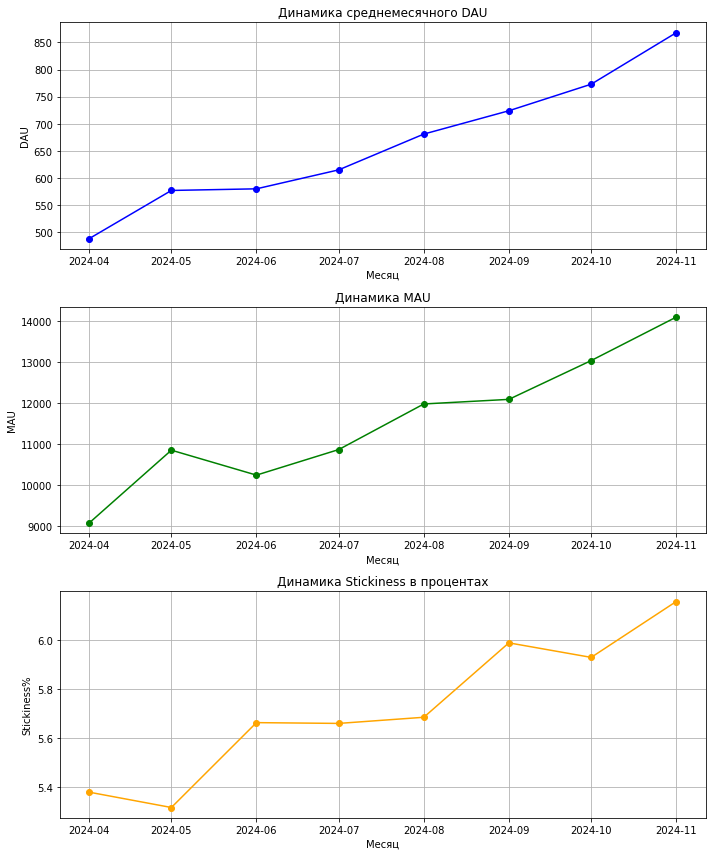

In [21]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 12))

# График для DAU
axes[0].plot(dau_mau_stick['month_dt'], dau_mau_stick['dau'], marker='o', color='blue')
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('DAU')
axes[0].set_title('Динамика среднемесячного DAU')
axes[0].grid()

# График для MAU
axes[1].plot(dau_mau_stick['month_dt'], dau_mau_stick['mau'], marker='o', color='green')
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('MAU')
axes[1].set_title('Динамика MAU')
axes[1].grid()

# График для Stickiness
axes[2].plot(dau_mau_stick['month_dt'], dau_mau_stick['stick'], marker='o', color='orange')
axes[2].set_xlabel('Месяц')
axes[2].set_ylabel('Stickiness%')
axes[2].set_title('Динамика Stickiness в процентах')
axes[2].grid()

plt.tight_layout()
plt.show()

<font color='#777778'>Динамика активности пользователей и их вовлечённости в продукт позитивна, 
    метрики общего DAU, MAU и Stickiness демонстрируют рост, что говорит о устойчивом интересе к продукту.
    </font> 

<font color='#00008B'>
<b>Задача 2:</b>
    </font> 

In [22]:
# Создаем дополнительные столбцы с первым месяцем активности в таблице profiles
profiles['first_month'] = profiles['first_dt'].dt.to_period('M').dt.to_timestamp()

# Находим среднемесячный CAC
CAC = profiles.groupby('first_month').agg(CAC =('day_cac', 'mean')).reset_index()
CAC

,first_month,CAC
0,2024-04-01,0.734706
1,2024-05-01,0.748572
2,2024-06-01,0.973978
3,2024-07-01,1.054344
4,2024-08-01,1.155601
5,2024-09-01,1.178301
6,2024-10-01,1.323047
7,2024-11-01,1.320148


In [23]:
# Создаем дополнительный столбец с месяце привлечения
orders_pro['first_month'] = orders_pro['first_dt'].dt.to_period('M').dt.to_timestamp()

# Фильтруем данные покупок, совершённых за 28 дней с момента привлечения, и осекаем неполные данные за ноябрь
orders_28 = orders_pro[(orders_pro['day_lifetime'] < 28) & (orders_pro['first_month'] < '2024-11-01')]

# находим суммарную выручку по месяцу привлечения
orders_28_month = orders_28.groupby(['first_month'])['revenue'].sum().reset_index()

# Считаем кол-во пользователей в когорте
cohort_sizes = profiles.groupby('first_month')['user_id'].nunique().reset_index()
cohort_sizes.columns = ['first_month', 'n_users']

# Присоединяем кол-во пользователей к данным о выручке и находим Когортный LTV (выручка / количество в когорте)
report = orders_28_month.merge(cohort_sizes, on='first_month')
report['LTV'] = report['revenue'] / report['n_users']

# Присоединям данные о среднем CAC
LTV_CAC_ROI = report.merge(CAC, on='first_month')

# Вычисляем ROI
LTV_CAC_ROI['ROI'] = (LTV_CAC_ROI['LTV'] - LTV_CAC_ROI['CAC']) / LTV_CAC_ROI['CAC'] *100

display(LTV_CAC_ROI)

,first_month,revenue,n_users,LTV,CAC,ROI
0,2024-04-01,7425.63,9069,0.818793,0.734706,11.444870
1,2024-05-01,8141.76,9789,0.831725,0.748572,11.108209
2,2024-06-01,7447.84,8719,0.854208,0.973978,-12.297015
3,2024-07-01,9991.41,8742,1.142920,1.054344,8.401051
4,2024-08-01,10367.05,9518,1.089205,1.155601,-5.745639
5,2024-09-01,10085.88,9198,1.096530,1.178301,-6.939783
6,2024-10-01,11449.71,9520,1.202701,1.323047,-9.096121


<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__
Срез логов по 28 день выполнен корректно. Молодец

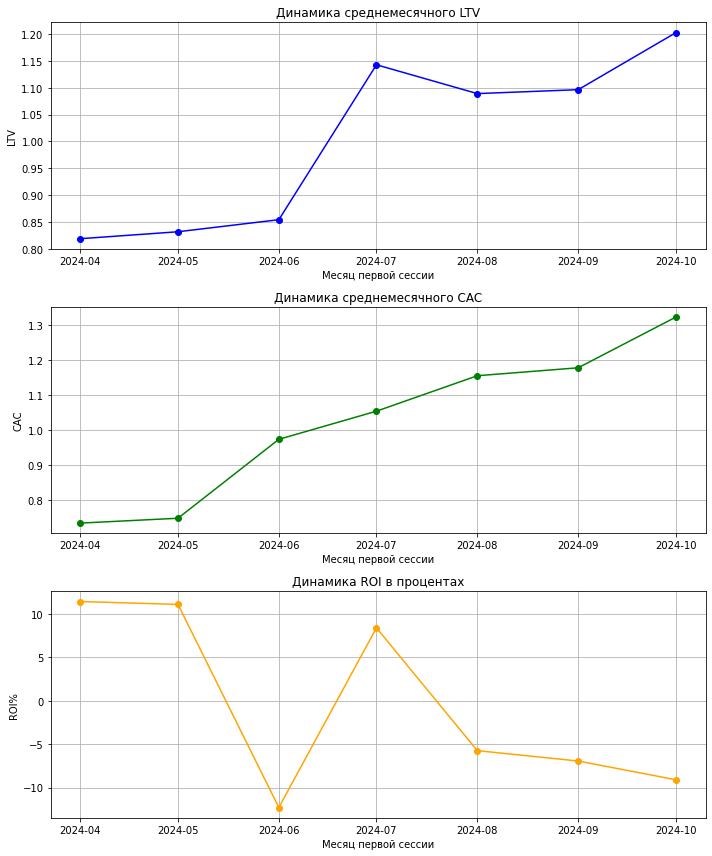

In [24]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 12))

# График для LTV
axes[0].plot(LTV_CAC_ROI['first_month'], LTV_CAC_ROI['LTV'], marker='o', color='blue')
axes[0].set_xlabel('Месяц первой сессии')
axes[0].set_ylabel('LTV')
axes[0].set_title('Динамика среднемесячного LTV')
axes[0].grid()

# График для CAC
axes[1].plot(LTV_CAC_ROI['first_month'], LTV_CAC_ROI['CAC'], marker='o', color='green')
axes[1].set_xlabel('Месяц первой сессии')
axes[1].set_ylabel('CAC')
axes[1].set_title('Динамика среднемесячного CAC')
axes[1].grid()

# График для ROI
axes[2].plot(LTV_CAC_ROI['first_month'], LTV_CAC_ROI['ROI'], marker='o', color='orange')
axes[2].set_xlabel('Месяц первой сессии')
axes[2].set_ylabel('ROI%')
axes[2].set_title('Динамика ROI в процентах')
axes[2].grid()

plt.tight_layout()
plt.show()

<font color='#00008B'>
<b>Вывод:</b></font><br>
<font color='#777778'>
    Динамика DAU, MAU и Stickiness показывает стабильный рост.<br>
    Динамика LTV и CAC демонстриует рост с июня, что совпадает с данными заказчика об измененении стратегии привлечения пользователей и появлении нового контента. ROI с июня резко падает до отрицательных значений, в июле возвращается к плюсу, далее с августа поступательно продолжает снижается в отрицательных значениях.<br>
    Возможно, введение нового контента оказалось интересным только части пользователей, резкий скачек LTV в июле вернул ROI в плюсовую зону, но потом затраты продолжили расти опережая доход и ROI продолжил снижение.
    </font> 

## Анализ метрик в разрезе источника привлечения

Теперь необходимо разобраться, какие источники привлечения перспективны, а какие за 28 дней не окупились.

**Задача 1**. Определим самые популярные источники привлечения:
- Посчитаем общее число привлечённых пользователей для каждого источника.
- Визуализируем динамику набора новых пользователей по дням в каждом источнике.
- Рассчитаем и визуализируем динамику DAU, MAU и Stickiness по источникам привлечения.

**Задача 2**. Изучим динамику изменения метрик на 28-й день в разрезе источника. Проведем анализ с выделением недельных когорт по дате привлечения. Рассчитаем и визуализируем:
- Скользящее удержание на 14-й день с момента привлечения (за период с 14-го по 28-й день).
- Конверсию в покупку.

Недельную динамику затрат на маркетинг по каждому источнику привлечения.
Динамику среднего CAC, значений LTV и ROI.

<font color='#00008B'>
<b>Задача 1:</b>
    </font> 

In [25]:
# Находим первый канал привлечения
pro_chan = visits.groupby('user_id').agg(first_channel=('channel', 'first')).reset_index()
visits_pro = visits_pro.merge(pro_chan, on='user_id')

In [26]:
# Находим общее число привлечённых пользователей
users_channel = visits_pro.groupby('first_channel')['user_id'].nunique().reset_index()
users_channel = users_channel.sort_values('user_id', ascending=False).reset_index()
users_channel

,index,first_channel,user_id
0,0,FaceBoom,28401
1,3,TipTop,18118
2,2,RocketSuperAds,14257
3,1,MediaTornado,14080


In [27]:
visits_pro

,user_id,region,device,channel,session_start,session_end,first_dt,month_dt,first_channel
0,631105188566,India,desktop,MediaTornado,2024-04-01,2024-04-01 04:19:00,2024-04-01,2024-04-01,MediaTornado
1,631105188566,India,desktop,MediaTornado,2024-04-02,2024-04-02 02:07:00,2024-04-01,2024-04-01,MediaTornado
2,200726430135,India,mobile,FaceBoom,2024-04-01,2024-04-01 07:22:00,2024-04-01,2024-04-01,FaceBoom
3,961353726572,India,desktop,RocketSuperAds,2024-04-01,2024-04-01 21:18:00,2024-04-01,2024-04-01,RocketSuperAds
4,1696591151,India,mobile,FaceBoom,2024-04-01,2024-04-01 10:46:00,2024-04-01,2024-04-01,FaceBoom
...,...,...,...,...,...,...,...,...,...
161860,159603580525,India,tv,FaceBoom,2024-11-30,2024-11-30 16:29:00,2024-11-30,2024-11-01,FaceBoom
161861,172376391837,India,desktop,RocketSuperAds,2024-11-30,2024-11-30 15:35:00,2024-11-30,2024-11-01,RocketSuperAds
161862,725382589767,India,mobile,RocketSuperAds,2024-11-30,2024-11-30 03:34:00,2024-11-30,2024-11-01,RocketSuperAds
161863,188139897674,India,desktop,MediaTornado,2024-11-30,2024-11-30 02:36:00,2024-11-30,2024-11-01,MediaTornado


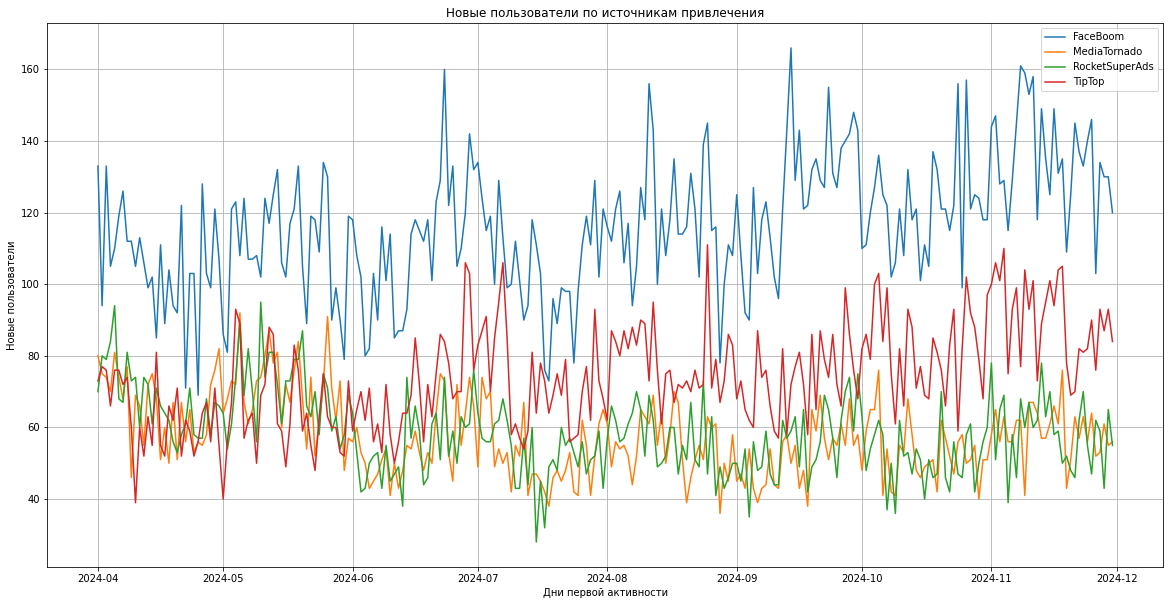

In [28]:
# Динамика набора новых пользователей по дням в каждом источнике
users_channel_day = visits_pro.groupby(['first_channel', 'first_dt'])['user_id'].nunique().reset_index()

plt.subplots(figsize=(20, 10))

for fc in users_channel_day['first_channel'].unique():
    plt.plot(users_channel_day[users_channel_day['first_channel'] == fc]['first_dt'],
             users_channel_day[users_channel_day['first_channel'] == fc]['user_id'])
    
plt.title('Новые пользователи по источникам привлечения')
plt.legend(users_channel_day['first_channel'].unique())
plt.xlabel('Дни первой активности')
plt.ylabel('Новые пользователи')
plt.grid()
plt.show() 

<font color='#777778'>
    Тенденцию усмотреть можно, но для наглядности посмотрим по месяцам:
    </font> 

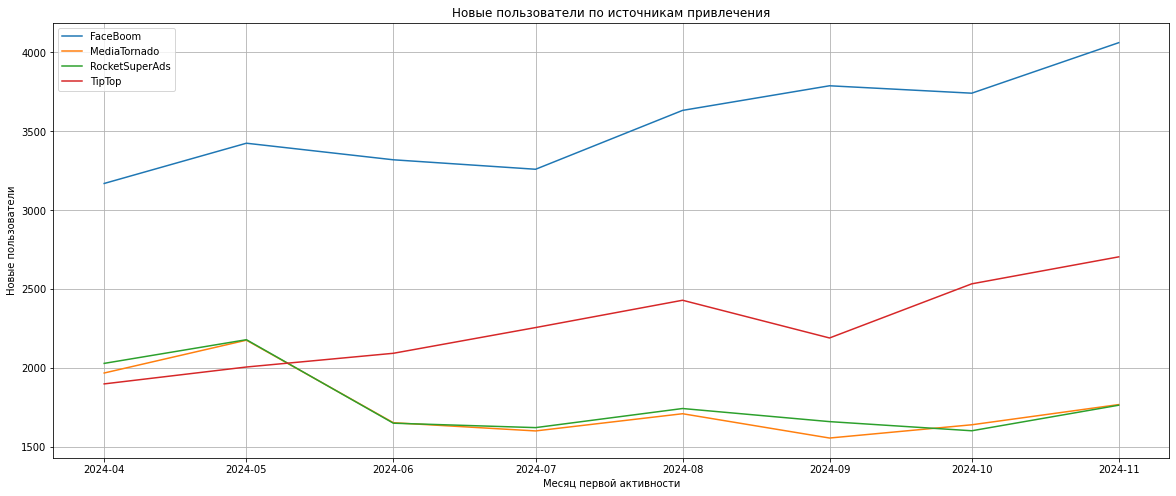

In [29]:
visits_pro['first_month'] = visits_pro['first_dt'].dt.to_period('M').dt.to_timestamp()

# Динамика набора новых пользователей по месяцам в каждом источнике
users_channel_month = visits_pro.groupby(['first_channel', 'first_month'])['user_id'].nunique().reset_index()

plt.subplots(figsize=(20, 8))

for fc in users_channel_month['first_channel'].unique():
    plt.plot(users_channel_month[users_channel_month['first_channel'] == fc]['first_month'],
             users_channel_month[users_channel_month['first_channel'] == fc]['user_id'])
    
plt.title('Новые пользователи по источникам привлечения')
plt.legend(users_channel_day['first_channel'].unique())
plt.xlabel('Месяц первой активности')
plt.ylabel('Новые пользователи')
plt.grid()
plt.show() 

In [30]:
# Находим DAU и потом среднемесячный DAU по каналам привлечения
dau_channel = visits_pro.groupby(['session_start', 'first_channel'])['user_id'].nunique().reset_index()
dau_channel['month_dt'] = dau_channel['session_start'].dt.to_period('M').dt.to_timestamp()
dau_avg_channel = dau_channel.groupby(['month_dt', 'first_channel']).agg(dau=('user_id', 'mean')).reset_index()
dau_avg_channel['dau'] = dau_avg_channel['dau'].round()

# Находим MAU по каналам привлечения
mau_channel = visits_pro.groupby(['month_dt', 'first_channel']).agg(mau=('user_id', 'nunique')).reset_index()

# Соединяем обе таблицы и находим Stickiness
dau_mau_stick_channel = pd.merge(dau_avg_channel, mau_channel, on=['month_dt', 'first_channel'])
dau_mau_stick_channel['stick'] = dau_mau_stick_channel['dau'] / dau_mau_stick_channel['mau'] *100

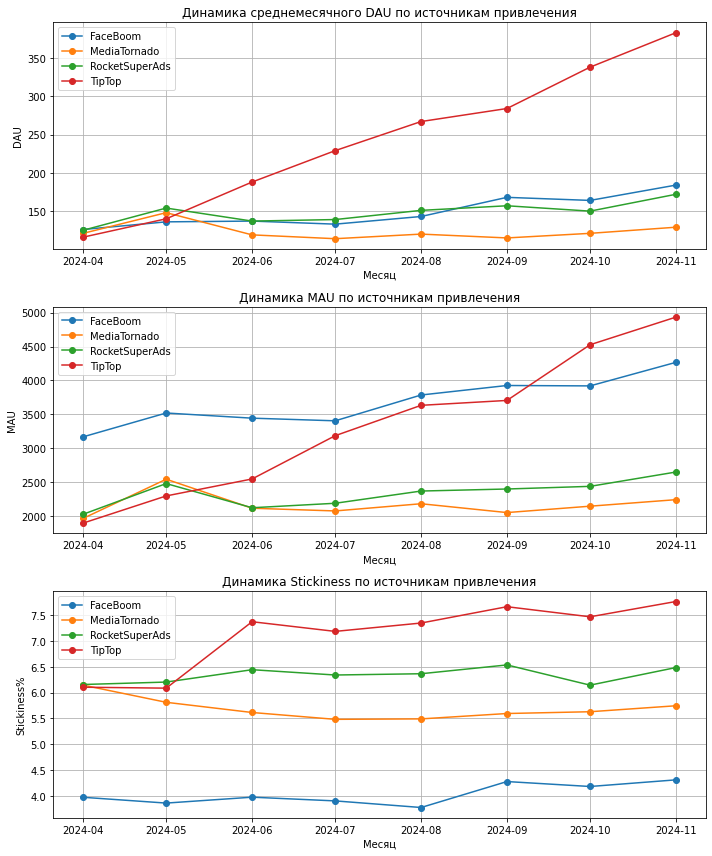

In [31]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 12))

# График для DAU
for fc in dau_mau_stick_channel['first_channel'].unique():
    axes[0].plot(dau_mau_stick_channel[dau_mau_stick_channel['first_channel'] == fc]['month_dt'],
                     dau_mau_stick_channel[dau_mau_stick_channel['first_channel'] == fc]['dau'], 
                     marker='o')
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('DAU')
axes[0].set_title('Динамика среднемесячного DAU по источникам привлечения')
axes[0].legend(dau_mau_stick_channel['first_channel'].unique())
axes[0].grid()
    
# График для MAU
for fc in dau_mau_stick_channel['first_channel'].unique():
    axes[1].plot(dau_mau_stick_channel[dau_mau_stick_channel['first_channel'] == fc]['month_dt'],
                     dau_mau_stick_channel[dau_mau_stick_channel['first_channel'] == fc]['mau'], 
                     marker='o')
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('MAU')
axes[1].set_title('Динамика MAU по источникам привлечения')
axes[1].legend(dau_mau_stick_channel['first_channel'].unique())
axes[1].grid()    

# График для Stickiness
for fc in dau_mau_stick_channel['first_channel'].unique():
    axes[2].plot(dau_mau_stick_channel[dau_mau_stick_channel['first_channel'] == fc]['month_dt'],
                     dau_mau_stick_channel[dau_mau_stick_channel['first_channel'] == fc]['stick'], 
                     marker='o')
axes[2].set_xlabel('Месяц')
axes[2].set_ylabel('Stickiness%')
axes[2].set_title('Динамика Stickiness по источникам привлечения')
axes[2].legend(dau_mau_stick_channel['first_channel'].unique())
axes[2].grid()    
    
plt.tight_layout()
plt.show()

<font color='#777778'>
Рост новых пользователей демострируют только каналы FaceBoom и TipTop<br>
Положительная динамика по DAU у канала TipTop. По MAU у FaceBoom и TipTop. По Stickiness только у TipTop с июня, что указывает на большую вовлеченность аудитории этого канала.
    </font>

<font color='#00008B'>
<b>Задача 2:</b><br>
    Скользящий Retention:
    </font> 

In [32]:
# Находим лайфтайм по дням
visits_pro['session_start'] = visits_pro['session_start'].dt.to_period('D')
visits_pro['first_dt'] = visits_pro['first_dt'].dt.to_period('D')
visits_pro['day_lifetime'] = visits_pro['session_start'].astype(int) - visits_pro['first_dt'].astype(int)

visits_pro['first_month'] = visits_pro['first_dt'].dt.to_timestamp().dt.to_period('M').dt.to_timestamp()

In [33]:
# Условия периода
min_day = 14
max_day = 28

# Фильтрация по максимальному дню
filtered1 = visits_pro[(visits_pro['day_lifetime'] < max_day)].copy()

# Юзеры нулевой когорты
base1 = (filtered1[filtered1['day_lifetime'] == 0].groupby(['first_channel', 'first_month']).agg(users_start=('user_id', 'nunique')).reset_index())

# Юзеры вернувшиеся на 14 день и позже
returned1 = filtered1[filtered1['day_lifetime'] >= min_day - 1].groupby(['first_channel', 'first_month']).agg(users_return=('user_id', 'nunique')).reset_index()

# Объединяем данные по нулевой когорте с вернувшимися, заменяя пропуски на 0 
retention1 = base1.merge(returned1, on=['first_channel', 'first_month'])

# Считаем Retention по дням
retention1['retention'] = retention1['users_return'] / retention1['users_start']

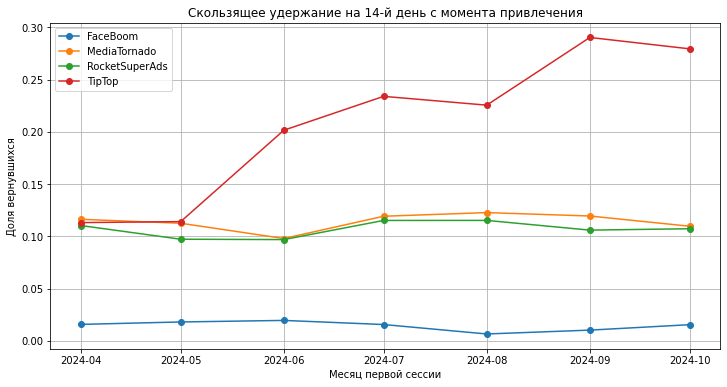

In [34]:
# Исключим последний месяц
retention1 = retention1[retention1['first_month'] < '2024-11-01']

# Строим линейный график
plt.subplots(figsize=(12,6))

for fc in retention1['first_channel'].unique():
    plt.plot(retention1[retention1['first_channel'] == fc]['first_month'],
                     retention1[retention1['first_channel'] == fc]['retention'], 
                     marker='o')

    
plt.title('Скользящее удержание на 14-й день с момента привлечения')
plt.xlabel('Месяц первой сессии')
plt.ylabel('Доля вернувшихся')
plt.legend(retention1['first_channel'].unique())
plt.grid()
plt.show()

<font color='#00008B'>
Конверсию в покупку:
    </font> 

,first_month,total_users,FaceBoom,MediaTornado,RocketSuperAds,TipTop
0,2024-04-01,777,46.718147,11.325611,20.592021,21.364221
1,2024-05-01,857,45.390898,12.485414,19.486581,22.637106
2,2024-06-01,758,50.000000,7.783641,15.567282,26.649077
3,2024-07-01,903,45.957918,7.198228,14.617940,32.225914
4,2024-08-01,881,41.997730,9.648127,16.004540,32.349603
5,2024-09-01,844,44.431280,8.649289,14.928910,31.990521
6,2024-10-01,897,40.133779,9.698997,14.715719,35.451505
7,2024-11-01,918,38.344227,8.169935,14.923747,38.562092


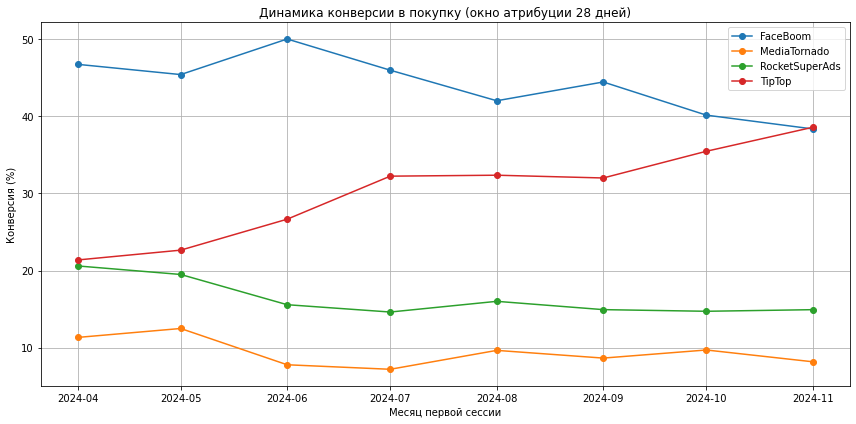

In [35]:
# Объединям данные о сессиях и покупках, заменяя получившиеся пропуски стоимости на ноль
vis_ord = visits.merge(orders, on='user_id', how='left')
vis_ord['revenue'] = vis_ord['revenue'].fillna(0)

# Находим дату первой сессии и первый канал привлечения
vis_ord['session_start'] = vis_ord['session_start'].dt.to_period('D').dt.to_timestamp()
profiles1 = visits.groupby('user_id').agg(first_dt=('session_start', 'min'), first_channel=('channel', 'first')).reset_index()

# Соединяем все в один датафрейм, и убираем ненужные столбцы 
vis_ord = vis_ord.merge(profiles1, on='user_id', how='left')
vis_ord_pro = vis_ord[['user_id', 'session_start', 'event_dt', 'revenue', 'first_dt', 'first_channel']]

# Определяем окно атрибуции
attribution_window = 28

# Считаем diff_days
#vis_ord_pro['diff_days'] = (vis_ord_pro['event_dt'] - vis_ord_pro['first_dt']).dt.days #На эту строку выдает SettingWithCopyWarning
vis_ord_pro = vis_ord_pro.assign(diff_days=(vis_ord_pro['event_dt'] - vis_ord_pro['first_dt']).dt.days)

# Округляем даты регистраций до месяца
vis_ord_pro['first_month'] = vis_ord_pro['first_dt'].dt.to_period('M').dt.to_timestamp()

# Фильтруем события в пределах окна атрибуции
vis_ord_pro = vis_ord_pro[vis_ord_pro['diff_days'].between(0, attribution_window)]

# Список каналов привлечения
channel_list = ["FaceBoom", "MediaTornado", "RocketSuperAds", "TipTop"]

# Считаем общее количество пользователей
funnel_dynamic = vis_ord_pro.groupby('first_month')['user_id'].nunique().reset_index(name='total_users')

plt.figure(figsize=(12, 6))

# Добавляем каналы в воронку
for channel in channel_list:
    df_event = vis_ord_pro[vis_ord_pro['first_channel'] == channel]
    # Считаем количество покупателей
    df_event = df_event[df_event['revenue'] > 0].groupby('first_month')['user_id'].nunique().reset_index(name=channel)
    funnel_dynamic = funnel_dynamic.merge(df_event, on='first_month', how='left')
    funnel_dynamic[channel] = (funnel_dynamic[channel] / funnel_dynamic['total_users']) * 100
    plt.plot(funnel_dynamic['first_month'], funnel_dynamic[channel], marker='o', label=channel)
    
display(funnel_dynamic)

plt.title('Динамика конверсии в покупку (окно атрибуции 28 дней)')
plt.xlabel('Месяц первой сессии')
plt.ylabel('Конверсия (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<font color='#00008B'>
  Недельная динамика среднего CAC, значений LTV и ROI:
    </font>

In [36]:
# Создаем дополнительный столбец с первой неделей активности в таблице profiles
profiles['first_week'] = profiles['first_dt'].dt.to_period('W').dt.to_timestamp()

# Находим недельный CAC по каналу привлечения
CAC_w = profiles.groupby(['first_week', 'first_channel']).agg(week_cac =('day_cac', 'mean')).reset_index()

# Фильтруем данные покупок, отсекая неполные данные за ноябрь и выбирая период 28 дней
orders_filt = orders_pro[(orders_pro['first_month'] < '2024-11-01') & (orders_pro['day_lifetime'] < 28)]

# Создаем дополнительный столбец с первой неделей активности
orders_filt = orders_filt.copy()
orders_filt['first_week'] = orders_filt['first_dt'].dt.to_period('W').dt.to_timestamp()

# находим суммарную выручку по неделе привлечения и каналу привлечения
orders_filt_week = orders_filt.groupby(['first_week', 'first_channel'])['revenue'].sum().reset_index()

# Считаем кол-во пользователей в когорте (неделя, канал)
profiles['first_week'] = profiles['first_dt'].dt.to_period('W').dt.to_timestamp()
cohort_sizes_w = profiles.groupby(['first_week', 'first_channel'])['user_id'].nunique().reset_index()
cohort_sizes_w.columns = ['first_week', 'first_channel', 'n_users']

# Присоединяем кол-во пользователей к данным о выручке и находим Когортный LTV (выручка / количество в когорте)
report_w = orders_filt_week.merge(cohort_sizes_w, on=['first_week', 'first_channel'])
report_w['LTV'] = report_w['revenue'] / report_w['n_users']

# Присоединям данные о среднем CAC
ltv_cav_roi = report_w.merge(CAC_w, on=['first_week', 'first_channel'])

# Вычисляем ROI
ltv_cav_roi['ROI'] = (ltv_cav_roi['LTV'] - ltv_cav_roi['week_cac']) / ltv_cav_roi['week_cac'] *100

# Добавляем столбец с номером недели
min_date = ltv_cav_roi['first_week'].min()
ltv_cav_roi['week_number'] = ((ltv_cav_roi['first_week'] - min_date) / pd.Timedelta('7 days')).astype(int) + 1

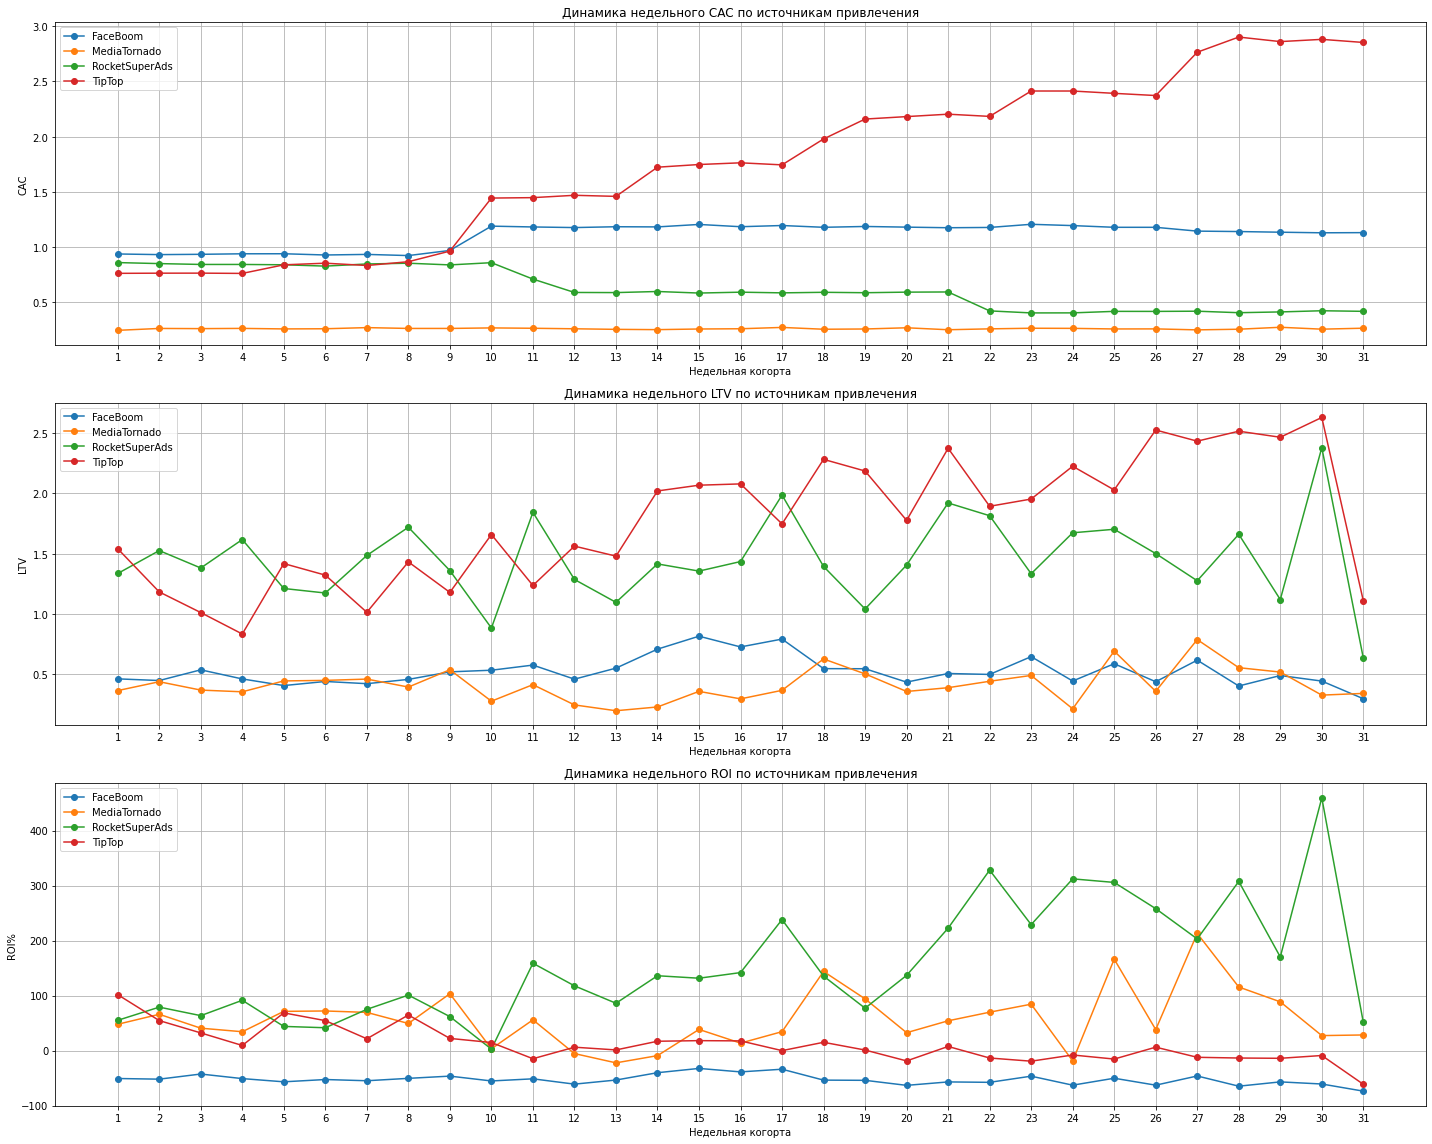

In [37]:
# Сроим графики
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(20, 16))

# График для CAC
for fc in ltv_cav_roi['first_channel'].unique():
    axes[0].plot(ltv_cav_roi[ltv_cav_roi['first_channel'] == fc]['week_number'],
                     ltv_cav_roi[ltv_cav_roi['first_channel'] == fc]['week_cac'], 
                     marker='o')
    
axes[0].set_xticks(ltv_cav_roi['week_number'].unique())      
axes[0].set_xlabel('Недельная когорта')
axes[0].set_ylabel('CAC')
axes[0].set_title('Динамика недельного CAC по источникам привлечения')
axes[0].legend(ltv_cav_roi['first_channel'].unique())
axes[0].grid()

# График для LTV
for fc in ltv_cav_roi['first_channel'].unique():
    axes[1].plot(ltv_cav_roi[ltv_cav_roi['first_channel'] == fc]['week_number'],
                     ltv_cav_roi[ltv_cav_roi['first_channel'] == fc]['LTV'], 
                     marker='o')

axes[1].set_xticks(ltv_cav_roi['week_number'].unique())     
axes[1].set_xlabel('Недельная когорта')
axes[1].set_ylabel('LTV')
axes[1].set_title('Динамика недельного LTV по источникам привлечения')
axes[1].legend(ltv_cav_roi['first_channel'].unique())
axes[1].grid()    

# График для ROI
for fc in ltv_cav_roi['first_channel'].unique():
    axes[2].plot(ltv_cav_roi[ltv_cav_roi['first_channel'] == fc]['week_number'],
                     ltv_cav_roi[ltv_cav_roi['first_channel'] == fc]['ROI'], 
                     marker='o')

axes[2].set_xticks(ltv_cav_roi['week_number'].unique())     
axes[2].set_xlabel('Недельная когорта')
axes[2].set_ylabel('ROI%')
axes[2].set_title('Динамика недельного ROI по источникам привлечения')
axes[2].legend(ltv_cav_roi['first_channel'].unique())
axes[2].grid()    
    
plt.tight_layout()
plt.show()

<font color='#00008B'>
<b>Вывод:</b></font><br>
<font color='#777778'>
FaceBoom - Привлекает наибольшее количество пользователей, таким и остается на протяжении периода изучения. DAU и MAU имеет незначительную тентенцию к росту, "Залипание" самый низкий из всех каналов, около 4%. Процент удержания тоже самый низкий, около 1%. Тем не менее конверсия в самая высокая, но имеет тенденцию к снижению. CAC повысился с июня (9 нед.) и стабилизировался на новом уровне около 1.2. LTV остается самым низким из всех, с июня тоже немного вырос и стабилизировался около 5. ROI стабильно самый низкий из всех.<br>
<br>
MediaTornado - Привлек наименьшее количество пользователей, таким и остается на протяжении периода изучения. DAU и MAU стабильно низкие из всех, "Залипание" выше чем у FaceBoom, колеблется около 5.5%. Процент удержания колеблется около 12%. Конверсия самая низкая, колеблется около 10%. CAC наименьший из всех, стабилен около 0.2. LTV в целом стабильно держится с колебаниями от ~5.5 до ~13. ROI в целом стабильно держится на самом высоком уровне, по сравнению с другими, колебания синхронны с динамикой LTV. <br>
<br>
RocketSuperAds - На третьем месте по количеству пользователей, таким и остается на протяжении периода изучения. DAU и MAU имеют тенденцию к росту, "Залипание", наоборот к снижению. 
    Процент удержания колеблется около 12%. Конверсия немного снизилась с июня, около 15%. CAC снизился с июня, стабилен. LTV самый высокий из всех, колеблется от 16 до 21. ROI имеет тенденцию к повышению <br>
<br>
TipTop - На втором месте по количеству пользователей, таким и остается на протяжении периода изучения. DAU, MAU имеют тенденцию к росту, "Залипание" вырос с июня и имеет тенденцию к росту. 
    Процент удержания резко растет с июня. Конверсия имеет тенденцию к росту с июня. CAC растет тоже с июня. LTV имеет тенденцию к росту. ROI, наоборот, снизился и стагнирует.<br> 
<br>
FaceBoom и TipTop за период 28 дней не продемонстрировали роста окупаемости. FaceBoom в минусе и стагнирует на протяжении всего периода, TipTop снизился и балансирует около нуля с минусовыми значениями.<br>
    Стагнация ROI канала FaceBoom связана с неизменной линией затрат и дохода. Снижение ROI канала TipTop, по всей видимости, связана с ростом затрат и c недостаточной положительной динамикой роста LTV. 
    </font> 

## Анализ периода окупаемости маркетинговых вложений

Для источников, которые к 28-му дню не выходят на уровень окупаемости, рассчитаем и визуализируем в виде тепловой карты значения ROI за больший период, например за 8–10 недель.

Разделим данные на недельные когорты по дате привлечения, в качестве интервала наблюдений используем недели.

In [38]:
# Фильтруем данные покупок, отсекая неполные данные за ноябрь и выбираем период 15 недель
orders_filt1 = orders_pro[(orders_pro['first_month'] < '2024-11-01') & (orders_pro['day_lifetime'] < 105)]

# Выбираем нужные каналы
orders_filt1 = orders_filt1[(orders_filt1['first_channel'] == 'FaceBoom') | (orders_filt1['first_channel'] == 'TipTop')]

# Создаем дополнительный столбец с первой неделей активности
orders_filt1 = orders_filt1.copy()
orders_filt1['first_week'] = orders_filt1['first_dt'].dt.to_period('W').dt.to_timestamp()
orders_filt1['event_week'] = orders_filt1['event_dt'].dt.to_period('W').dt.to_timestamp()

# Считаем возраст когорты в неделях
orders_filt1['n_week'] = ((orders_filt1['event_week'] - orders_filt1['first_week']).dt.days // 7).astype('Int64')

# находим суммарную выручку по неделе привлечения и каналу привлечения и недельному интревалу
orders_filt_week1 = orders_filt1.groupby(['first_week', 'first_channel', 'n_week'])['revenue'].sum().reset_index()

# Сортируем по неделе привлечения, каналу привлечения и недельному интревалу
orders_filt_week1 = orders_filt_week1.sort_values(by=['first_week', 'first_channel', 'n_week'])

# Кумулятивная выручка по когорте
orders_filt_week1['cum_revenue'] = orders_filt_week1.groupby(['first_week', 'first_channel'])['revenue'].cumsum()

# Присоединяем кол-во пользователей к данным о выручке и находим Когортный LTV (Кумулятивная выручка / количество в когорте)
report_w1 = orders_filt_week1.merge(cohort_sizes_w, on=['first_week', 'first_channel'])
report_w1['LTV'] = report_w1['cum_revenue'] / report_w1['n_users']

# Присоединям данные о среднем CAC
ltv_cav_roi1 = report_w1.merge(CAC_w, on=['first_week', 'first_channel'])

# Вычисляем ROI
ltv_cav_roi1['ROI'] = (ltv_cav_roi1['LTV'] - ltv_cav_roi1['week_cac']) / ltv_cav_roi1['week_cac'] *100

# Добавляем столбец с номером недели
min_date1 = ltv_cav_roi1['first_week'].min()
ltv_cav_roi1['week_number'] = ((ltv_cav_roi1['first_week'] - min_date1) / pd.Timedelta('7 days')).astype(int) + 1

In [39]:
# Сводная таблица для канала FaceBoom
roi_fb = ltv_cav_roi1[ltv_cav_roi1['first_channel'] == 'FaceBoom'].pivot_table(
                      index='week_number', columns='n_week', values='ROI', aggfunc='mean')

# Кумулятивная сумма ROI по неделям жизни канала FaceBoom
ltv_cumulative_fb = roi_fb.cumsum(axis=1).round(2)


# Сводная таблица для канала TipTop
roi_tt = ltv_cav_roi1[ltv_cav_roi1['first_channel'] == 'TipTop'].pivot_table(
                      index='week_number', columns='n_week', values='ROI', aggfunc='mean')

# Кумулятивная сумма ROI по неделям жизни канала TipTop
ltv_cumulative_tt = roi_tt.cumsum(axis=1).round(2)


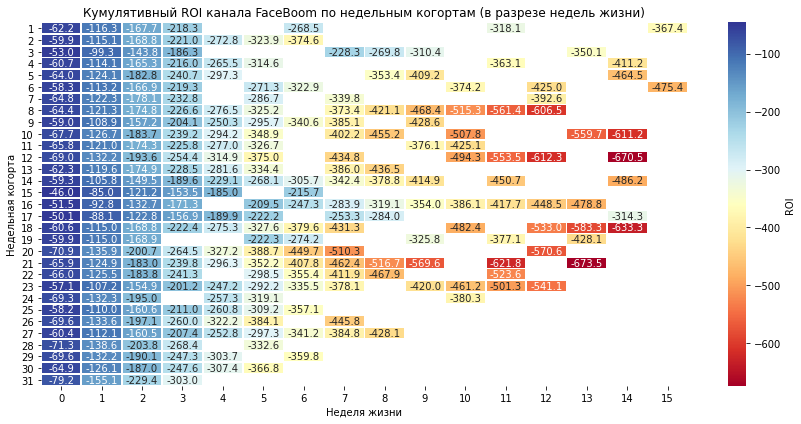

In [40]:
# График для канала FaceBoom
plt.figure(figsize=(12, 6))

sns.heatmap(
    ltv_cumulative_fb,
    annot=True,
    annot_kws={"size": 10},
    fmt=".1f",
    cmap="RdYlBu",
    linewidths=0.8,
    cbar_kws={'label': 'ROI'})

plt.title('Кумулятивный ROI канала FaceBoom по недельным когортам (в разрезе недель жизни)')
plt.xlabel('Неделя жизни')
plt.ylabel('Недельная когорта')
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

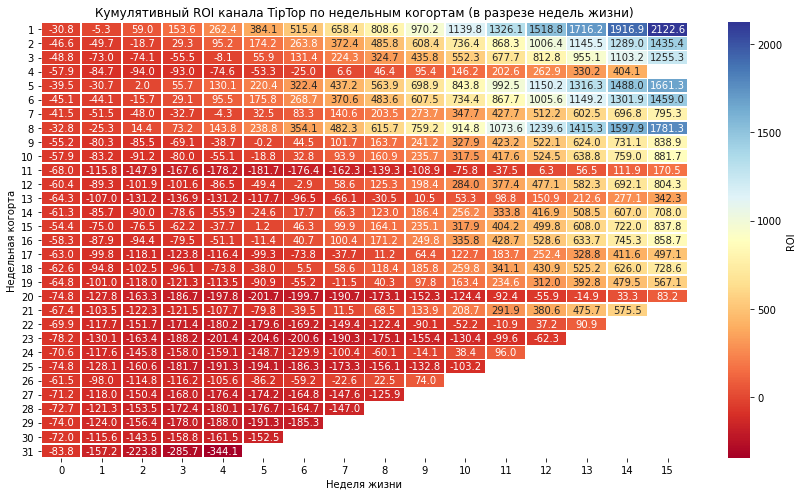

In [41]:
# График для канала TipTop
plt.figure(figsize=(12, 7))

sns.heatmap(
    ltv_cumulative_tt,
    annot=True,
    annot_kws={"size": 10},
    fmt=".1f",
    cmap="RdYlBu",
    linewidths=0.8,
    cbar_kws={'label': 'ROI'})

plt.title('Кумулятивный ROI канала TipTop по недельным когортам (в разрезе недель жизни)')
plt.xlabel('Неделя жизни')
plt.ylabel('Недельная когорта')
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

<font color='#00008B'>
<b>Вывод:</b></font><br>
<font color='#777778'>
FaceBoom - Не окупается даже за 15 недель. по всем недельным когортам ситуация с отрицательной окупаемостью только прогрессирует.<br>
<br>
TipTop - Более ранние когорты, до июня (9 неделя), в целом окупаются лучше более поздних, у которых срок окупаемости увеличен в два три раза по сравнению с уставовленным бизнес-моделью в 4 недели.<br> 
    </font> 

## Выводы и рекомендации

<font color='#00008B'>
<b>Вывод:</b></font><br>
<font color='#777778'>
Наблюдается утойчивый рост общего MAU, DAU и "Залипания", что указывает на устойчивый интерес к продукту.<br>
В тоже время, рост новых пользователей по источникам привлечения только у каналов FaceBoom и TipTop, метрика двух других каналов, MediaTornado и RocketSuperAds снизилась с июня и остается стабильной с практически одинаковыми значениями.<br>
При этом, канал TipTop демонстрирует существенный поступательный рост MAU и DAU от месяца к месяцу, "Залипание" резко выросло с июня и показывает тенденцию к росту. Так же тенденцию к росту показывает MAU канала FaceBoom, но процент Залипания остается самым низким из всех без существенных колебаний. Те же метрики двух других каналов без существенных изменений, стабильны.<br> 
Все это свидетельствует о неравномерной эффективности привлечения по каналам.<br>
<br>
Резкий рост Скользящего удержания (на 14-й день с момента привлечения) демонстрирует только канал TipTop с июня. Графики остальных каналов держатся на одном уровне без изменений.<br> 
Динамика конверсии в покупку имеет рост только у канала TipTop. Метрика канала FaceBoom снижается. Остальные два без аномалий, стабильны.<br>
<br>
    
Общий ROI имеет резкий спад в июне до отрицательных значений, потом резкий подъем в июле в плюсовую зону, и далее, с августа уходит в минус и продолжает поступательное снижение. Это "зигзаг" синхронен с резким подъемом LTV в августе и поступательным ростом затрат (CAC) с июня.<br>
Анализ этих метрик по каналам выявил следующее:<br>
    Для канала <b>TipTop</b> наблюдается существенный ступенчатый (каждые 4 недели) рост затрат на привлечение (CAC), опережающий рост LTV, при этом растет количество новых пользователей. Динамика ROI имеет тенденцию к снижению с июня, балансирую около нуля с заходом в отрицательные значения на горизонте 28 дней(4 нед.). Рассмотрение более длителного срока (15 нед.), показало, что канал в целом выходит на окупаемость, но срок увеличен в два три раза по сравнению с уставовленным бизнес-моделью.<br>
    Канал <b>FaceBoom</b>, повысив уровень затрат на привлечение с июня, остается неизменным по этой метрике, повышая количество новых пользователей. LTV при этом без существенных колебаний, не превышая уровня затрат. ROI стабильно держится ниже нуля без с особых колебаний. Рассмотрение этой метрики на более длителном сроке в 15 нед, не выявил ее перехода в плюсовые значения.<br>
    Канал <b>MediaTornado</b> имеет практически неизменный уровень затрат и приток пользователей. LTV с колебаниями незначительно первышающими затраты. В целом окупается за установленый срок в 4 недели.<br>
    Канал <b>RocketSuperAds</b> ступенчато снизил уровень затрат, сначала с июня, далее еще раз с сентября (22 неделя), при стабильном притоке новых пользователей. LTV существенно превышает уровень затрат, делая ROI положительным с тенеденцией к росту на отрезке 4 недели.<br>
 <br>
    По всей видимости, причиной стагнации выручки (<b>ROI</b>) является отрицательная динамика этой метрики у двух каналов - <b>TipTop</b> и <b>FaceBoom</b>, последний вносит в это наибольший вклад.
    </font> 

<font color='#00008B'>
<b>Рекомендации:</b></font><br>
<font color='#777778'>
Учитывая, что канал <b>FaceBoom</b> не окупается даже при долгосрочной перспективе, следует прежде всего обратить внимание на качество аудитории, привлеченной через него. Ведь метрики прилипания и удержания самые низкие из всех и остаются неизменными, а конверсия в покупку имеет тенденцию к снижению. Эти обстоятельства указывают на то, что вовлеченность пользователей, пришедших через этот канал мала, а это не способствует покупкам. Возможно спортивный контент им не так интересен. Стоит оптимизировать затраты на привлечение, таргетируя более ценную аудитории или, при невозможности это сделать, рассмотреть отказ от этого канала. <br>
<br>
Канал <b>TipTop</b> имеет самую лояльную аудиторию по метрике прилипания, которая растет. А также самый высокий показатель удержания, который тоже растет, конверсию в покупателя, и тоже с тенденцией к росту. Но при этом этот канал имеет самые высокие затраты на привлечение, которые увеличиваются ступенчато от месяца к месяцу, и которые операжают рост дохода от пользователей. Можно пожертвовать скоростью прироста новых пользователей ради уже имеющихся, снизив затраты на привлечение. 
    </font> 